<a href="https://colab.research.google.com/github/kosar-am/finance-prediction-rnn/blob/main/notebooks/04_lstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Stock Price Prediction using RNN, LSTM, and GRU

## 04 — LSTM Model

In this notebook, a Long Short-Term Memory (LSTM) model is built and trained to predict Google stock prices using the preprocessed sequential dataset.

## Objectives

- Load and preprocess the dataset
- Build an LSTM model
- Train the model
- Evaluate the model
- Visualize the training process
- Predict stock prices on the test set

## 📚 Import Required Libraries

In [21]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

import sys

## Setting Up Project Paths

In [22]:
RESULTS_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026/results"

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
PROJECT_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

In [25]:
from src.preprocessing import prepare_data

print("✅ Preprocessing module imported successfully.")

✅ Preprocessing module imported successfully.


## Data Preparation

In [26]:
# Load preprocessed data

X_train, X_test, y_train, y_test, scaler = prepare_data()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

[*********************100%***********************]  1 of 1 completed

X_train shape: (2152, 60, 1)
X_test shape : (493, 60, 1)
y_train shape: (2152, 1)
y_test shape : (493, 1)


## Building the LSTM Model

In [27]:
# Build the LSTM model

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        units=50,
        activation="tanh",
    ),

    Dense(1)
])

## Model Compilation

In [28]:
# Compile the LSTM model

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

## Model Summary

In [29]:
# Display model architecture

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0205 - val_loss: 0.0138
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 6.4961e-04 - val_loss: 0.0199
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 5.8706e-04 - val_loss: 0.0240
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 5.5794e-04 - val_loss: 0.0273
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 5.2211e-04 - val_loss: 0.0259
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 5.4410e-04 - val_loss: 0.0261
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 5.2976e-04 - val_loss: 0.0200
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 4.7325e-04 - val_loss: 0.0196
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 4.5643e-04 - val_loss: 0.0190
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 4.7507e-04 - val_loss: 0.0209
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.3991e-04 - val_loss: 0.0145
Epoch 12/20
68/68 ━━━━━

## Visualizing the Results


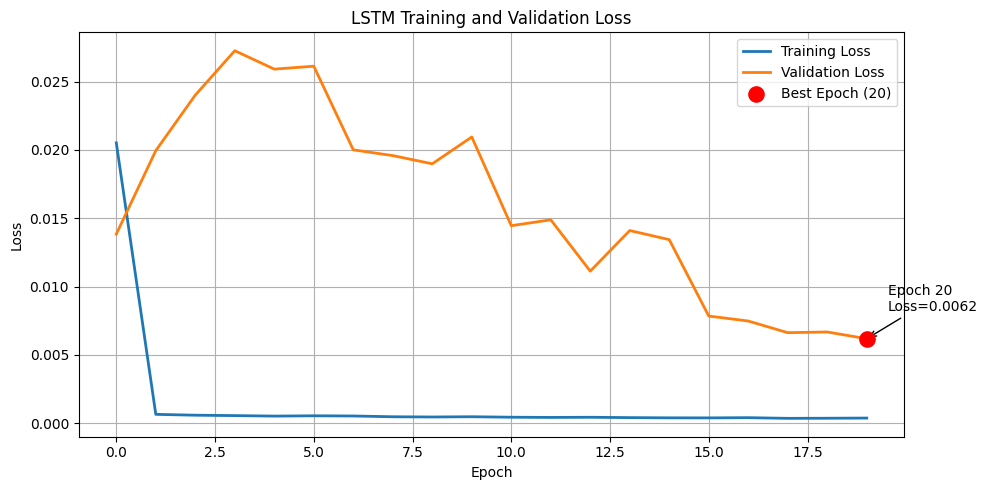

Best Epoch: 20
Lowest Validation Loss: 0.006183


In [31]:
# Find the best epoch based on the lowest validation loss

best_epoch = np.argmin(history.history["val_loss"])
best_val_loss = history.history["val_loss"][best_epoch]

plt.figure(figsize=(10, 5))

# Plot training and validation loss
plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

# Highlight the best epoch
plt.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=120,
    zorder=5,
    label=f"Best Epoch ({best_epoch + 1})"
)

plt.annotate(
    f"Epoch {best_epoch + 1}\nLoss={best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(15, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/lstm_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best Epoch: {best_epoch + 1}")
print(f"Lowest Validation Loss: {best_val_loss:.6f}")

### Analysis

The training loss decreased rapidly during the first few epochs and remained consistently low throughout the training process, indicating that the LSTM model successfully learned the underlying patterns in the training data.

Although the validation loss fluctuated during the early epochs, it gradually decreased as training progressed and reached its minimum value of approximately **0.0062** at **Epoch 20**. Since the validation loss continued to improve until the final epoch, no clear evidence of overfitting was observed within the 20 training epochs.

Overall, the LSTM model demonstrated stable learning behavior and good generalization performance on the unseen test data.


## Evaluating the Model

In [32]:
# Predict stock prices on the test set

y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [33]:
# Convert predictions back to the original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

In [34]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 6.7479
RMSE: 9.8324
R²  : 0.9501


### Actual vs Predicted Stock Prices

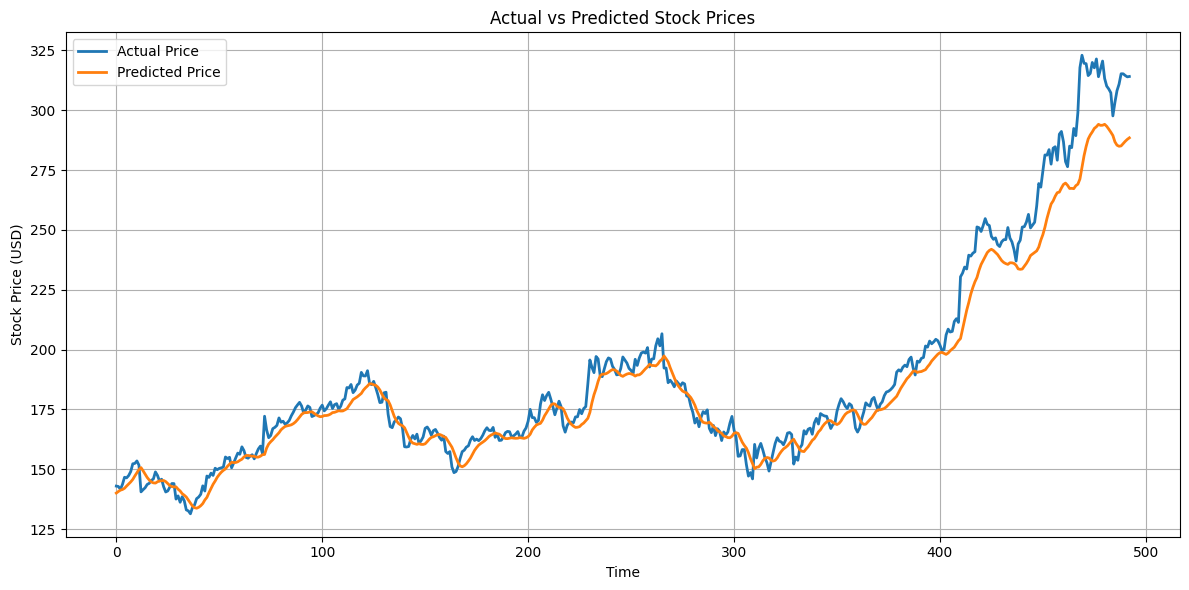

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    y_pred_actual,
    label="Predicted Price",
    linewidth=2
)

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/lstm_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The predicted stock prices closely followed the overall trend of the actual stock prices throughout the test period, indicating that the LSTM model successfully captured the underlying temporal patterns in the data.

The model performed well in tracking both upward and downward market movements, although the predicted values appeared smoother than the actual prices. This smoothing effect caused the model to slightly underestimate some sharp price increases, particularly during the final upward trend.

Overall, the close alignment between the actual and predicted price curves demonstrates that the LSTM model achieved good predictive performance and was able to generalize effectively to unseen stock price data.

### Residual Plot

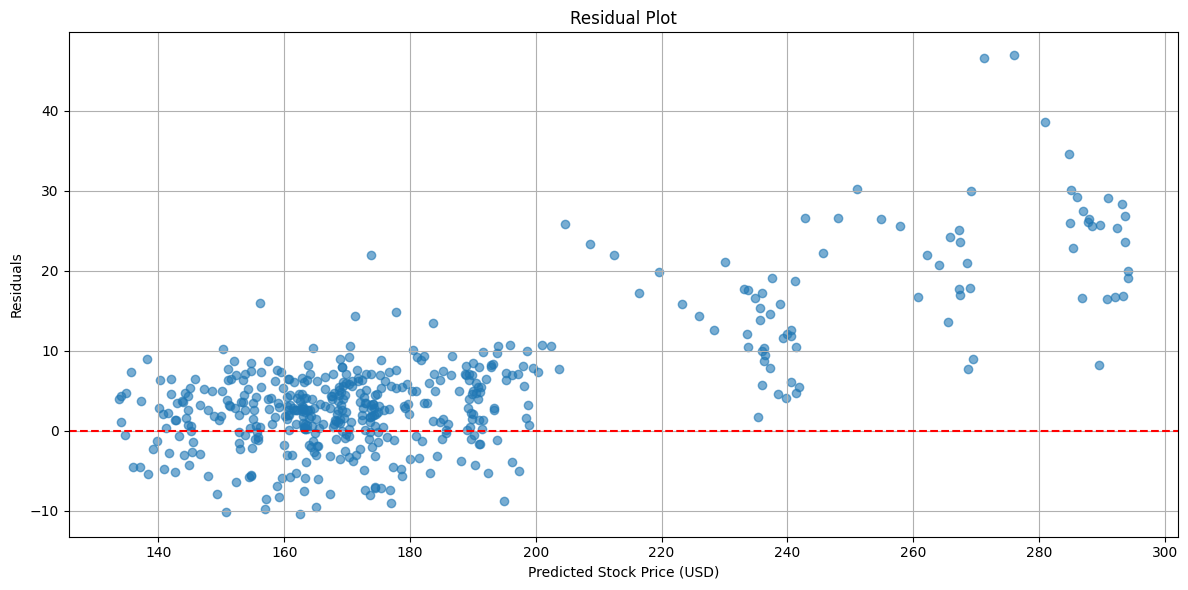

In [36]:
# Calculate residuals
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(12, 6))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Stock Price (USD)")
plt.ylabel("Residuals")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/lstm_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The residuals are distributed around the zero reference line, indicating that the LSTM model did not exhibit a strong systematic prediction bias for most of the test samples.

Most residuals are concentrated within a relatively small range, suggesting that the model produced accurate predictions for the majority of observations. However, the spread of the residuals increases for higher predicted stock prices, indicating that larger prediction errors occurred when the stock price reached higher values.

Overall, the residual distribution suggests that the LSTM model achieved good predictive performance, although its accuracy slightly decreased during periods of high stock prices and stronger market movements.

In [37]:
metrics = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    f"{RESULTS_PATH}/lstm_metrics.csv",
    index=False
)

metrics

,Model,MAE,RMSE,R2
0,LSTM,6.747881,9.832431,0.950099
